# NB01 Text Representation (Axis1)

## Member1 (Rui): TF-IDF Unigrams & Bigrams (full data)
 Input: nlp_abstracts_cleaned.csv

 Output: tfidf_unigram_matrix.pkl, tfidf_bigram_matrix.pkl

**Note**: 
This version is based on **entire data**. 
 For neural network models like BERT, 3000+ lines (10% sampled) of data is too little. 

 To facilitate subsequent model training, **the current version processes the full dataset**.

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("../data/nlp_abstracts_cleaned.csv")

In [3]:
print(f"TOTAL: {len(df)}")
print(df["period"].value_counts().sort_index())

TOTAL: 32221
period
1991-1995      448
1996-2000      659
2001-2005      279
2006-2010      364
2011-2015     2066
2016-2021    28405
Name: count, dtype: int64


In [4]:
# text cleaning
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def clean_abstract(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   
    text = re.sub(r"\s+", " ", text).strip()

    tt = text.split()
    tt = [lemmatizer.lemmatize(w, pos='v') for w in tt]
    tt = [lemmatizer.lemmatize(w, pos='n') for w in tt]
    text = " ".join(tt)

    return text

[nltk_data] Downloading package wordnet to /Users/dekai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
from tqdm.auto import tqdm
tqdm.pandas()

# df["abstract_clean"] = df["abstract"].apply(clean_abstract)

df["abstract_clean"] = df["abstract"].progress_apply(clean_abstract)

df = df[df["abstract_clean"].str.len() > 20].copy()
print(f"the Number of Papers after Cleaning: {len(df)}")

  0%|          | 0/32221 [00:00<?, ?it/s]

AttributeError: 'Series' object has no attribute '_is_builtin_func'

### Fitting TF-IDF

In [6]:
# sublinear_tf=True  --- use log to take word frequency, compress the weight of high-frequency words
# min_df=5 --- at least appears in 5 papers
# max_df=0.85 ---remove words that appear in more than 85% of the papers
# max_features=20000 --- keep the top 20000 features (words or n-grams) based on term frequency


vectorizer_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.85,
    max_features=20000,
    stop_words="english",
    sublinear_tf=True,
)

vectorizer_bi = TfidfVectorizer(
    ngram_range=(2, 2),
    min_df=5,
    max_df=0.85,
    max_features=20000,
    stop_words="english",
    sublinear_tf=True,
)


In [7]:
uni_matrix = vectorizer_uni.fit_transform(df["abstract_clean"])
bi_matrix = vectorizer_bi.fit_transform(df["abstract_clean"])

print(f"the shape of Unigram: {uni_matrix.shape}")
print(f"the shape of Bigram: {bi_matrix.shape}")

KeyError: 'abstract_clean'

In [8]:
# Save for later use
with open("../outputs/tfidf_unigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     uni_matrix,
        "vectorizer": vectorizer_uni,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)

with open("../outputs/tfidf_bigram_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix":     bi_matrix,
        "vectorizer": vectorizer_bi,
        "index":      df.index,
        "period":     df["period"].values,
        "era":        df["era"].values,
    }, f)


NameError: name 'uni_matrix' is not defined

### TOP20 keywords

The number of papers varies greatly from period to period (1991-1995 about 448 papers, 2016-2021 about 28405 papers).
If the TF-IDF scores are summed using `.sum()`, the late period has much higher scores than the early period due to the large number of papers, resulting in the curve of all words in the early period being compressed to nearly 0, and the early and late periods are not comparable.
The result is that the curves for all words in the early period are compressed to close to 0, and the early and late periods are not comparable.

The change to `.mean()` when filtering by period can help to calculate the average TF-IDF score of each period.

In [9]:
def top_terms_per_period(matrix, vectorizer, df, period_col="period", top_n=20):
    """
    dict: {period: [(term, score), ...]}
    method: Sum the TF-IDF scores of all papers in each period and take the top_n.
    """
    feat = vectorizer.get_feature_names_out()
    periods = sorted(df[period_col].unique())
    results = {}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten() 
            # use mean to eliminate sample size differences to make word weights comparable across time periods
        top_idx = summed.argsort()[::-1][:top_n]
        results[period] = [(feat[i], round(summed[i], 2)) for i in top_idx]
    return results


print("\nUnigram Top 20 per period ")
uni_top = top_terms_per_period(uni_matrix, vectorizer_uni, df, top_n=20)
for period, terms in uni_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")

print("\nBigram Top 20 per period ")
bi_top = top_terms_per_period(bi_matrix, vectorizer_bi, df, top_n=20)
for period, terms in bi_top.items():
    print(f"{period}: {', '.join(t[0] for t in terms)}")



Unigram Top 20 per period 


NameError: name 'uni_matrix' is not defined

### Vocabulary Comparison

In [10]:
# Vocabulary Comparison Across Periods (Rise VS. Disappearance)
def vocab_shift(top_terms_dict, early_periods, late_periods):
    early_words = set()
    late_words  = set()
    for p in early_periods:
        if p in top_terms_dict:
            early_words.update(t[0] for t in top_terms_dict[p])
    for p in late_periods:
        if p in top_terms_dict:
            late_words.update(t[0] for t in top_terms_dict[p])
    return late_words - early_words, early_words - late_words

early = ["1991-1995", "1996-2000", "2001-2005"]
late  = ["2011-2015", "2016-2021"]

uni_emerged, uni_disappeared = vocab_shift(uni_top, early, late)
print(f"\nUnigram emerging words: {sorted(uni_emerged)}")
print(f"Unigram disappearing words: {sorted(uni_disappeared)}")

bi_emerged, bi_disappeared = vocab_shift(bi_top, early, late)
print(f"\nBigram emerging words: {sorted(bi_emerged)}")
print(f"Bigram disappearing words: {sorted(bi_disappeared)}")



NameError: name 'uni_top' is not defined

### Representative vocabulary changes by period

In [11]:
def plot_term_trends(matrix, vectorizer, df, terms, period_col="period", title=""):
    feat  = list(vectorizer.get_feature_names_out())
    periods = sorted(df[period_col].unique())
    valid = [t for t in terms if t in feat]
    if not valid:
        print("None specified terms")
        return

    scores = {t: [] for t in valid}
    for period in periods:
        mask = (df[period_col] == period).values
        # summed = np.asarray(matrix[mask].sum(axis=0)).flatten()
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        for t in valid:
            scores[t].append(summed[feat.index(t)])

    fig, ax = plt.subplots(figsize=(12, 5))
    for t, vals in scores.items():
        v = np.array(vals)
        if v.max() > 0:
            v = v / v.max()
        ax.plot(periods, v, marker="o", label=t)

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Normalised TF-IDF Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../figures/{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

unigram_track = ["neural", "transformer", "attention", "parsing", "statistical", "pretrained"]
plot_term_trends(uni_matrix, vectorizer_uni, df, unigram_track, title="Unigram_Term(all)")

bigram_track = ["neural network", "language model", "machine translation",
                "deep learning", "pre trained", "hidden markov"]
plot_term_trends(bi_matrix, vectorizer_bi, df, bigram_track, title="Bigram_Term(all)")



NameError: name 'uni_matrix' is not defined

Based on the Unigram and Bigram timelines, we derived three key insights that perfectly illustrate the historic paradigm shift in NLP from the "Statistical Era" to the "Deep Learning Era":

#### 1. The "Death Cross" and Neural Dominance (Unigram)
* **The Exit of Statistical Methods**: The term `statistical`, representing traditional machine learning, dominated from the 1990s to the early 2000s but began an irreversible decline after 2010.
* **The Neural Takeover**: The trajectory of `neural` forms a perfect intersection with `statistical` between 2011 and 2015, marking the exact period when early neural networks began disrupting NLP.
* **The Large Model Explosion**: Most strikingly, `transformer`, `attention`, and `pretrained` were practically non-existent before 2015, but skyrocketed almost vertically between 2016 and 2021. This precisely aligns with the introduction of the Transformer architecture (2017) and pre-trained models like BERT (2018).

#### 2. The Fall of Classic Models and Paradigm Updates (Bigram)
* **The Twilight of Hidden Markov**: `hidden markov` maintained extreme popularity for two decades (1991-2010) as the backbone of sequence labeling. However, post-2010, it suffered a cliff-like drop, being entirely phased out by the deep learning boom.
* **The Rise of Pre-training**: Corresponding with the unigram trends, `language model` and `pre trained` strongly peaked in the last five years, indicating a fundamental shift from "task-specific model design" to the "pre-trained language model + fine-tuning" paradigm.

## Member 2 (Dekai): SBERT Embeddings & LDA Topic Model (full data)
Output: period_labels.pkl,sbert_matrix.pkl,lda_matrix.pkl

In [12]:
# SBERT: encode each abastract into a dense semantic vector.
from sentence_transformers import SentenceTransformer

#gensim tools for topic modelling.
from gensim import corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel

#Cosine similarity for period-level semantic comparison.
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

### Saving period labels
Saving index, period, and era as a stable reference so that later analyses(cosine distance, PCA, report tables) could stay aligned.

In [13]:
with open("../outputs/period_labels.pkl", "wb") as f:
    pickle.dump({
        "index": df.index,
        "period": df["period"].values,
        "era": df["era"].values,
    }, f)

print("Saved: ../..outputs/period_labels.pkl")

Saved: ../..outputs/period_labels.pkl


### SBERT Embeddings
This section encodes each abstract into a dense semantic vector using a SentenceTransformer model.
The goal is to capture semantic drift across time periods, beyond surface-level vocabulary change.  

#### Peparing data for SBERT
Method(clean_abstract) was designed for TF-IDF. It removes punctuation, numbers, and formatting aggressively. SBERT usually works better with more natural sentence-like input. So it is better to keep the text closer to natural language.

In [14]:
#Make a copy.
df_sbert = df.copy()
#Clean the data.
df_sbert["abstract_sbert"] = df_sbert["abstract"].fillna("").astype(str).str.strip()
#Filter out extremely short texts.
df_sbert = df_sbert[df_sbert["abstract_sbert"].str.len() > 20].copy()

print("Number of paper for SBERT:", len(df_sbert))
df_sbert[["abstract_sbert", "period"]].head()

Number of paper for SBERT: 32221


,abstract_sbert,period
0,In this paper Arabic was investigated from the...,2006-2010
1,In this paper we present the creation of an Ar...,2006-2010
2,"In this paper, we propose an automated evaluat...",2006-2010
3,Intelligent Input Methods (IM) are essential f...,2006-2010
4,This paper includes a reflection on the role o...,2006-2010


#### Loading SBERT model

In [15]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

print("SBERT model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT model loaded


#### Encoding abstracts with SBERT
The method of model(encode()) could transforms each abstract into an embedding vector.

In [16]:
sbert_matrix = sbert_model.encode(
    df_sbert["abstract_sbert"].tolist(),
    #process 500 abstracts at a time
    batch_size=500,
    #display progress while encoding.
    show_progress_bar=True,
    #return a NumPy array.
    convert_to_numpy=True
)

print("SBERT matrix shape:", sbert_matrix.shape)
print("Embedding dimension:", sbert_matrix.shape[1])

Batches:   0%|          | 0/65 [00:00<?, ?it/s]

SBERT matrix shape: (32221, 384)
Embedding dimension: 384


In [17]:
# Save SBERT matrix
with open("../outputs/sbert_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix": sbert_matrix,
        "model_name": "all-MiniLM-L6-v2",
        "index": df_sbert.index,
        "period": df_sbert["period"].values,
        "era": df_sbert["era"].values,
    }, f)

print("Saved: outputs/sbert_matrix.pkl")

Saved: outputs/sbert_matrix.pkl


#### Computing semantic similarity by period

In [18]:
# Get all unique periods and sort them.
periods_sbert = sorted(df_sbert["period"].unique())
# Compute one centroid (average embedding) per period.
period_centroids = []

for period in periods_sbert:
    #Create a boolean mask
    bool_mask = (df_sbert["period"] == period).values
    # Average all document embeddings in this period.
    centroid = sbert_matrix[bool_mask].mean(axis=0)
    period_centroids.append(centroid)

# Stack all centroids into one matrix
period_centroids = np.vstack(period_centroids)

print("Period centroid matrix shape:", period_centroids.shape)

# Compute cosine similarity between period centroids.
semantic_similarity = cosine_similarity(period_centroids)

# Convert to DataFrame.
similarity_df = pd.DataFrame(
    semantic_similarity,
    index=periods_sbert,
    columns=periods_sbert
)

print("Semantic similarity matrix:")
similarity_df
    

Period centroid matrix shape: (6, 384)
Semantic similarity matrix:


,1991-1995,1996-2000,2001-2005,2006-2010,2011-2015,2016-2021
1991-1995,1.000000,0.984785,0.944259,0.933870,0.864053,0.740509
1996-2000,0.984785,1.000000,0.973756,0.948581,0.915566,0.806360
2001-2005,0.944259,0.973756,1.000000,0.970150,0.947571,0.824442
2006-2010,0.933870,0.948581,0.970150,1.000000,0.927628,0.772103
2011-2015,0.864053,0.915566,0.947571,0.927628,1.000000,0.930171
2016-2021,0.740509,0.806360,0.824442,0.772103,0.930171,1.000000


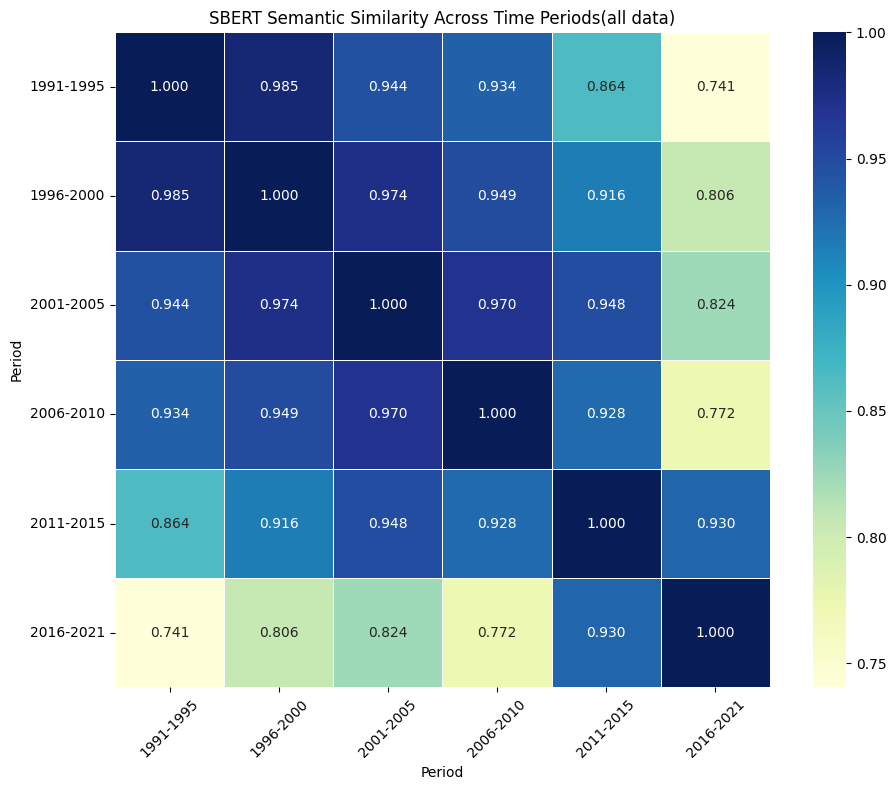

In [19]:
# Draw the heatmap.

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    square=True,
    linewidths=0.5
)

plt.title("SBERT Semantic Similarity Across Time Periods(all data)")
plt.xlabel("Period")
plt.ylabel("Period")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The Similarity heatmap shows that periods close in time are more similar, while periods far apart are more different. This means NLP changed gradually, but the long-term change is substantial.

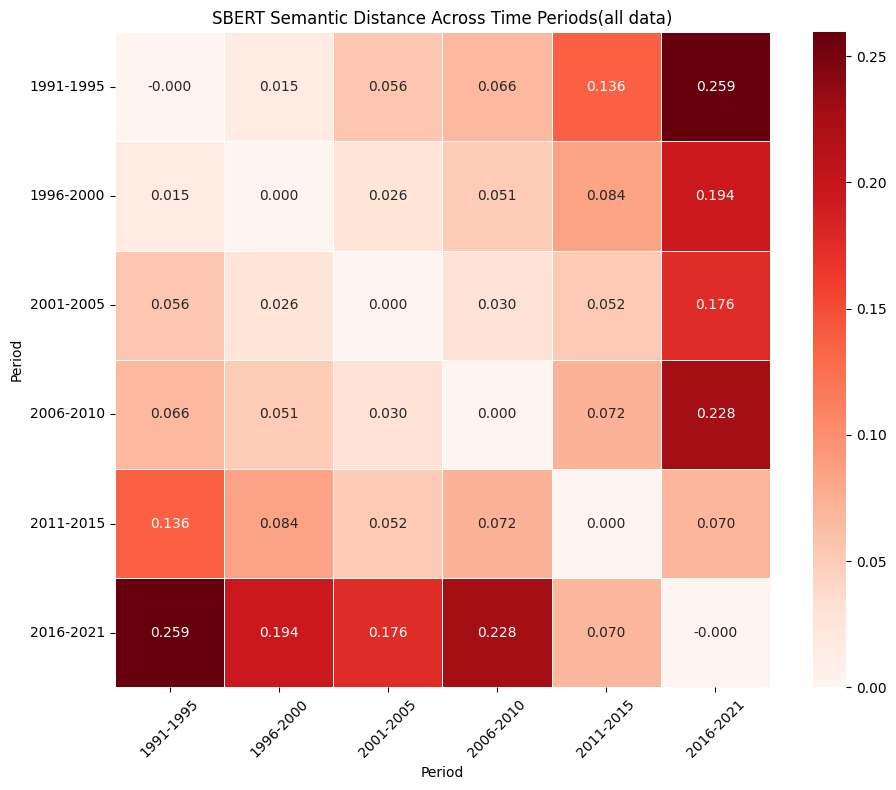

In [20]:
# draw the distance heatmap
distance_df = 1 - similarity_df

plt.figure(figsize=(10, 8))

sns.heatmap(
    distance_df,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    square=True,
    linewidths=0.5
)

plt.title("SBERT Semantic Distance Across Time Periods(all data)")
plt.xlabel("Period")
plt.ylabel("Period")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The distance heatmap shows that early NLP and recent NLP are the most different, suggesting that the field’s research focus and way of describing work have changed a lot over time.

### LDA Topic Model
This section models each abstract as a mixture of latent topics.  
The goal is to examine how topic proportions change across historical periods.  

In [21]:
# Make a copy
df_lda = df.copy()

print("Initial number of papers for LDA:", len(df_lda))

Initial number of papers for LDA: 32221


In [22]:
# Cleaning function for LDA
# Clean one abstract and return a token list for LDA.
# standard English stopwords.
base_stopwords = set(ENGLISH_STOP_WORDS)

#generic academic filler words
academic_stopwords = {
    "paper", "papers",
    "approach", "approaches",
    "method", "methods",
    "propose", "proposed",
    "present", "presents",
    "show", "shows",
    "study", "studies",
    "using", "used", "use",
    "based"
}

custom_stopwords = base_stopwords.union(academic_stopwords)
def clean_for_lda(text):
    if not isinstance(text, str):
        return []
    
    # Lowercase all text.
    text = text.lower()
    
    # Keep only letters and spaces.
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Replace multiple spaces with one space, then strip edges.
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenize by spaces.
    tokens = text.split()
    
    # Remove very short tokens.
    tokens = [t for t in tokens if len(t) > 2]

    # Remove stopwords.
    tokens = [t for t in tokens if t not in custom_stopwords]
    
    return tokens

In [23]:
# Tokenize abstracts for LDA
df_lda["abstract_lda_tokens"] = df_lda["abstract"].apply(clean_for_lda)

# Remove documents with too few tokens.
df_lda = df_lda[df_lda["abstract_lda_tokens"].map(len) > 5].copy()

print("Number of papers for LDA after filtering:", len(df_lda))
df_lda[["abstract_lda_tokens", "period"]].head()

Number of papers for LDA after filtering: 32217


,abstract_lda_tokens,period
0,"[arabic, investigated, speech, recognition, pr...",2006-2010
1,"[creation, arabic, version, automated, speech,...",2006-2010
2,"[automated, evaluation, metric, text, entry, c...",2006-2010
3,"[intelligent, input, essential, making, text, ...",2006-2010
4,"[includes, reflection, role, networks, english...",2006-2010


In [24]:
# Create a dictionary from all tokenized abstracts.
lda_dictionary = corpora.Dictionary(df_lda["abstract_lda_tokens"])

# Remove extreme words:
# - no_below=5: keep words appearing in at least 5 documents
# - no_above=0.85: remove words appearing in more than 85% of documents
lda_dictionary.filter_extremes(no_below=5, no_above=0.85)

# Convert each document into bag-of-words format.
lda_corpus = [lda_dictionary.doc2bow(tokens) for tokens in df_lda["abstract_lda_tokens"]]

print("Dictionary size", len(lda_dictionary))
print("Corpus size", len(lda_corpus))

Dictionary size 12860
Corpus size 32217


#### Choosing K for LDA
Choosing appropriate K for LDA model through comparison of different values.

In [25]:
k_values = [8, 10, 15]
coherence_results = []

for k in k_values:
    lda_k = LdaModel(
        corpus=lda_corpus,
        id2word=lda_dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        chunksize=1000,
        alpha="auto",
        per_word_topics=False
    )
    
    coherence_model = CoherenceModel(
        model=lda_k,
        texts=df_lda["abstract_lda_tokens"].tolist(),
        dictionary=lda_dictionary,
        coherence="c_v"
    )
    
    coherence = coherence_model.get_coherence()
    coherence_results.append((k, coherence))
    print(f"K={k}, coherence={coherence:.4f}")

K=8, coherence=0.5101
K=10, coherence=0.5082
K=15, coherence=0.5127


#### Training LDA model
LDA represents each document as a mixture of latent topics.
Each topic is a distribution over words.

In [33]:
num_topics = 15

lda_model = LdaModel(
    corpus=lda_corpus,          
    id2word=lda_dictionary,     
    num_topics=num_topics,  
    # fixed random seed
    random_state=42,
    # number of passes over the corpus
    passes=10, 
    # batch size
    chunksize=1000, 
    # automatically learn alpha
    alpha="auto",               
    per_word_topics=False
)

print("LDA model trained")

LDA model trained


In [35]:
# Check topics
for topic_id in range(num_topics):
    print(f"Topic {topic_id}:")
    print(lda_model.print_topic(topic_id, topn=10))

Topic 0:
0.045*"dialogue" + 0.027*"shot" + 0.025*"user" + 0.022*"human" + 0.020*"systems" + 0.016*"metrics" + 0.015*"conversational" + 0.015*"dialog" + 0.013*"response" + 0.013*"evaluation"
Topic 1:
0.094*"translation" + 0.084*"languages" + 0.060*"english" + 0.045*"multilingual" + 0.039*"language" + 0.038*"machine" + 0.030*"cross" + 0.027*"resource" + 0.026*"lingual" + 0.020*"parallel"
Topic 2:
0.056*"document" + 0.044*"text" + 0.042*"documents" + 0.036*"news" + 0.035*"summarization" + 0.030*"topic" + 0.020*"content" + 0.018*"articles" + 0.016*"information" + 0.016*"style"
Topic 3:
0.280*"language" + 0.108*"natural" + 0.074*"processing" + 0.040*"nlp" + 0.025*"code" + 0.018*"text" + 0.013*"understanding" + 0.013*"modal" + 0.011*"languages" + 0.010*"english"
Topic 4:
0.053*"generation" + 0.051*"question" + 0.034*"questions" + 0.027*"reasoning" + 0.027*"image" + 0.026*"answering" + 0.025*"encoder" + 0.024*"answer" + 0.023*"visual" + 0.016*"dataset"
Topic 5:
0.042*"word" + 0.029*"words" + 

#### Building dense LDA matrix

In [36]:
# Create an empty matrix
lda_matrix = np.zeros((len(lda_corpus), num_topics))

for i, bow in enumerate(lda_corpus):
    # Get topic probabilities for one document.
    doc_topics = lda_model.get_document_topics(bow, minimum_probability=0)
    
    # Fill the dense matrix.
    for topic_id, prob in doc_topics:
        lda_matrix[i, topic_id] = prob

print("LDA matrix shape:", lda_matrix.shape)

LDA matrix shape: (32217, 15)


In [37]:
#save LDA matrix
with open("../outputs/lda_matrix.pkl", "wb") as f:
    pickle.dump({
        "matrix": lda_matrix,
        "num_topics": num_topics,
        "dictionary": lda_dictionary,
        "index": df_lda.index,
        "period": df_lda["period"].values,
        "era": df_lda["era"].values,
    }, f)

print("Saved: ../outputs/lda_matrix.pkl")

Saved: ../outputs/lda_matrix.pkl


#### Computing topic proportions per period

In [38]:
# Get sorted period labels.
periods_lda = sorted(df_lda["period"].unique())

# Store the average topic distribution for each period.
topic_by_period = []

for period in periods_lda:
    bool_mask = (df_lda["period"] == period).values
    
    topic_mean = lda_matrix[bool_mask].mean(axis=0)
    topic_by_period.append(topic_mean)

# Convert to a 2D array.
topic_by_period = np.vstack(topic_by_period)

# Convert to DataFrame.
topic_period_df = pd.DataFrame(
    topic_by_period,
    index=periods_lda,
    columns=[f"Topic_{i}" for i in range(num_topics)]
)

print("Topic proportions per period:")
topic_period_df

Topic proportions per period:


,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10,Topic_11,Topic_12,Topic_13,Topic_14
1991-1995,0.033087,0.027731,0.014554,0.036922,0.021307,0.178084,0.049516,0.022878,0.091115,0.063189,0.149862,0.012433,0.097713,0.032195,0.169414
1996-2000,0.033684,0.021755,0.017361,0.037071,0.019970,0.173349,0.047444,0.028294,0.068119,0.072379,0.179072,0.013662,0.105545,0.031371,0.150925
2001-2005,0.034051,0.026514,0.036589,0.041081,0.022945,0.151234,0.049361,0.026028,0.040253,0.089822,0.170970,0.021594,0.100628,0.037015,0.151915
2006-2010,0.027830,0.026580,0.043300,0.045190,0.019695,0.168786,0.049130,0.021473,0.042332,0.085477,0.137363,0.025772,0.098931,0.031173,0.176968
2011-2015,0.030238,0.029424,0.040041,0.039275,0.028217,0.150096,0.074107,0.023551,0.027477,0.067285,0.196919,0.046395,0.070084,0.033399,0.143494
2016-2021,0.043896,0.031432,0.031599,0.030535,0.043089,0.088637,0.097793,0.024126,0.016777,0.048166,0.300673,0.038398,0.050189,0.037318,0.117371


In [39]:
#show top topics by period
for period in periods_lda:
    print(f"Top topics for {period}:")
    print(topic_period_df.loc[period].sort_values(ascending=False).head(3))

Top topics for 1991-1995:
Topic_5     0.178084
Topic_14    0.169414
Topic_10    0.149862
Name: 1991-1995, dtype: float64
Top topics for 1996-2000:
Topic_10    0.179072
Topic_5     0.173349
Topic_14    0.150925
Name: 1996-2000, dtype: float64
Top topics for 2001-2005:
Topic_10    0.170970
Topic_14    0.151915
Topic_5     0.151234
Name: 2001-2005, dtype: float64
Top topics for 2006-2010:
Topic_14    0.176968
Topic_5     0.168786
Topic_10    0.137363
Name: 2006-2010, dtype: float64
Top topics for 2011-2015:
Topic_10    0.196919
Topic_5     0.150096
Topic_14    0.143494
Name: 2011-2015, dtype: float64
Top topics for 2016-2021:
Topic_10    0.300673
Topic_14    0.117371
Topic_6     0.097793
Name: 2016-2021, dtype: float64


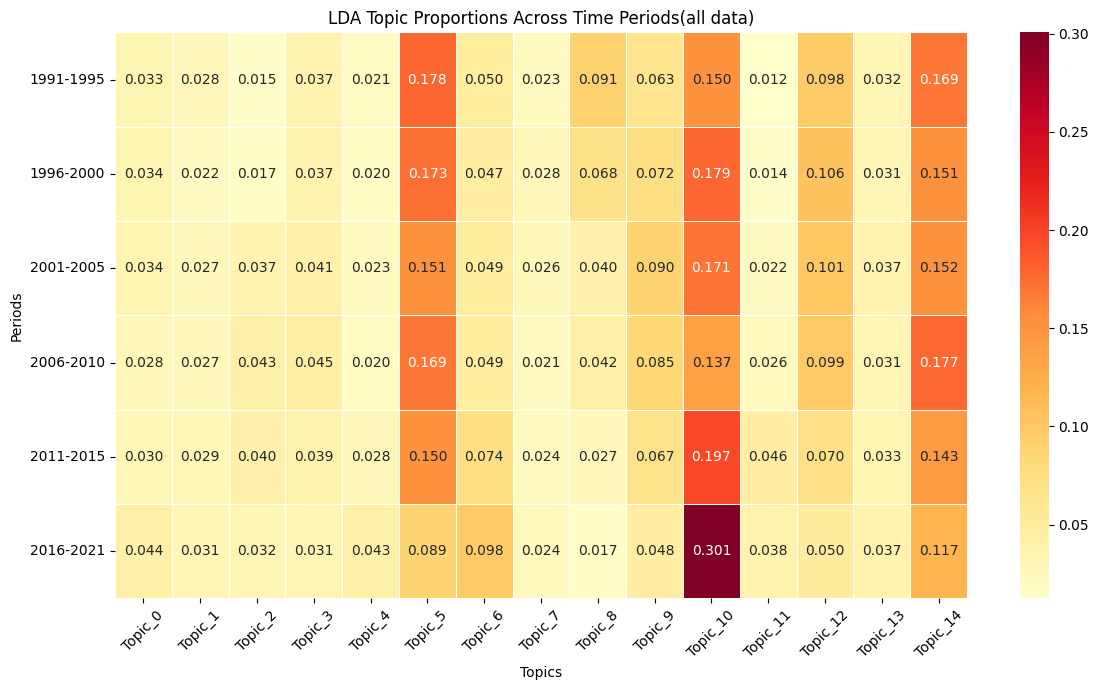

In [42]:
# Draw heatmap of topic proportions by period.
plt.figure(figsize=(12, 7))

sns.heatmap(
    topic_period_df,
    annot=True,        
    fmt=".3f",           
    cmap="YlOrRd",       
    linewidths=0.5
)

plt.title("LDA Topic Proportions Across Time Periods(all data)")
plt.xlabel("Topics")
plt.ylabel("Periods")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The heatmap shows that topic composition changes across historical periods rather than remaining constant. In particular, Topic_10 becomes much more prominent in 2016--2021, while Topic_8 declines steadily from the earliest period, suggesting a shift from earlier themes toward newer model-oriented topics.

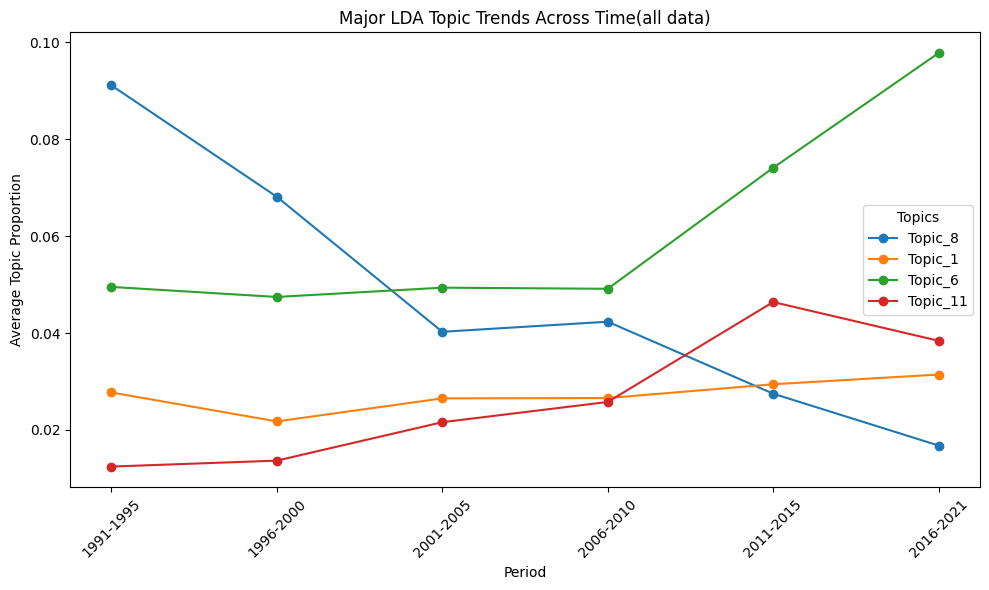

In [43]:
# Select the topics which need to track.
selected_topics = ["Topic_8", "Topic_1", "Topic_6", "Topic_11"]

plt.figure(figsize=(10, 6))

for topic in selected_topics:
    plt.plot(
        topic_period_df.index,
        topic_period_df[topic],
        marker="o",
        label=topic
    )

plt.title("Major LDA Topic Trends Across Time(all data)")
plt.xlabel("Period")
plt.ylabel("Average Topic Proportion")

plt.xticks(rotation=45)
plt.legend(title="Topics")
plt.tight_layout()
plt.show()

Topic_8 shows a clear long-term decline, whereas Topic_6 and Topic_11 rise more strongly in later periods, especially after 2011--2015. Topic_1 remains relatively stable, indicating that NLP research changed through a mixture of declining, emerging, and persistent themes.